In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('diabetes.csv')

# Check how many zeros exist in columns where 0 is impossible
cols_to_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Zero counts in each column:")
for col in cols_to_check:
    zero_count = (df[col] == 0).sum()
    print(f"  {col}: {zero_count} zeros")

Zero counts in each column:
  Glucose: 5 zeros
  BloodPressure: 35 zeros
  SkinThickness: 227 zeros
  Insulin: 374 zeros
  BMI: 11 zeros


Replace zeros with NaN then fill with median

In [2]:
# Replace impossible zeros with NaN
df[cols_to_check] = df[cols_to_check].replace(0, np.nan)

print("Missing values after replacing zeros:")
print(df.isnull().sum())

Missing values after replacing zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [3]:
# Fill missing values with the median of each column
df.fillna(df.median(numeric_only=True), inplace=True)

print("Missing values after filling:")
print(df.isnull().sum())  # Should all be 0

Missing values after filling:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Engineer new features
This is what makes your project stand out. You're creating new columns from existing ones that give the model more meaningful signals.

In [4]:
# BMI category (standard medical classification)
df['BMI_Category'] = pd.cut(
    df['BMI'],
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

# Age group
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=['Young', 'Middle', 'Senior', 'Elderly']
)

# Glucose risk level (based on real medical thresholds)
df['Glucose_Risk'] = pd.cut(
    df['Glucose'],
    bins=[0, 99, 125, 300],
    labels=['Normal', 'Pre-diabetic', 'Diabetic']
)

print("New columns added:")
print(df[['BMI', 'BMI_Category', 'Age', 'Age_Group', 'Glucose', 'Glucose_Risk']].head(10))

New columns added:
    BMI BMI_Category  Age Age_Group  Glucose  Glucose_Risk
0  33.6        Obese   50    Senior    148.0      Diabetic
1  26.6   Overweight   31    Middle     85.0        Normal
2  23.3       Normal   32    Middle    183.0      Diabetic
3  28.1   Overweight   21     Young     89.0        Normal
4  43.1        Obese   33    Middle    137.0      Diabetic
5  25.6   Overweight   30     Young    116.0  Pre-diabetic
6  31.0        Obese   26     Young     78.0        Normal
7  35.3        Obese   29     Young    115.0  Pre-diabetic
8  30.5        Obese   53    Senior    197.0      Diabetic
9  32.3        Obese   54    Senior    125.0  Pre-diabetic


C:\Users\vidit\AppData\Local\Temp\ipykernel_28924\2696718732.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bmi_risk, x='BMI_Category', y='Diabetes_Rate', palette='Reds')


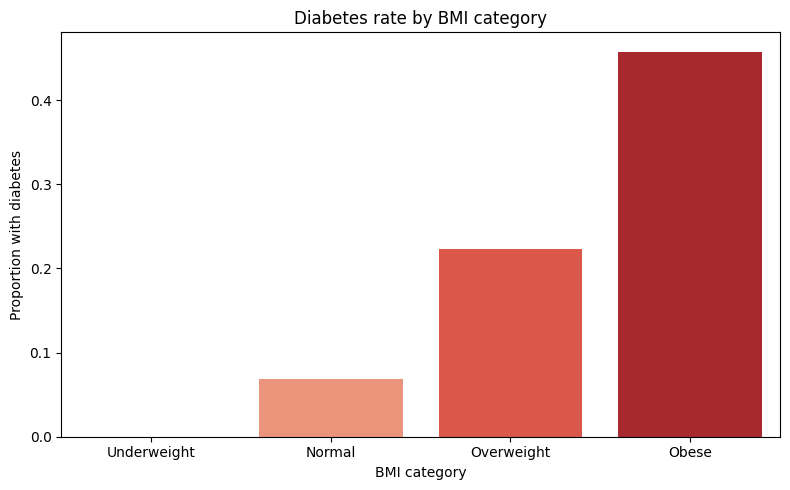

Chart saved!


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Diabetes rate by BMI category
bmi_risk = df.groupby('BMI_Category', observed=True)['Outcome'].mean().reset_index()
bmi_risk.columns = ['BMI_Category', 'Diabetes_Rate']

plt.figure(figsize=(8, 5))
sns.barplot(data=bmi_risk, x='BMI_Category', y='Diabetes_Rate', palette='Reds')
plt.title('Diabetes rate by BMI category')
plt.ylabel('Proportion with diabetes')
plt.xlabel('BMI category')
plt.tight_layout()
plt.savefig('charts/diabetes_by_bmi.png')
plt.show()
print("Chart saved!")

C:\Users\vidit\AppData\Local\Temp\ipykernel_28924\3124930817.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=glucose_risk, x='Glucose_Risk', y='Diabetes_Rate', palette='Oranges')


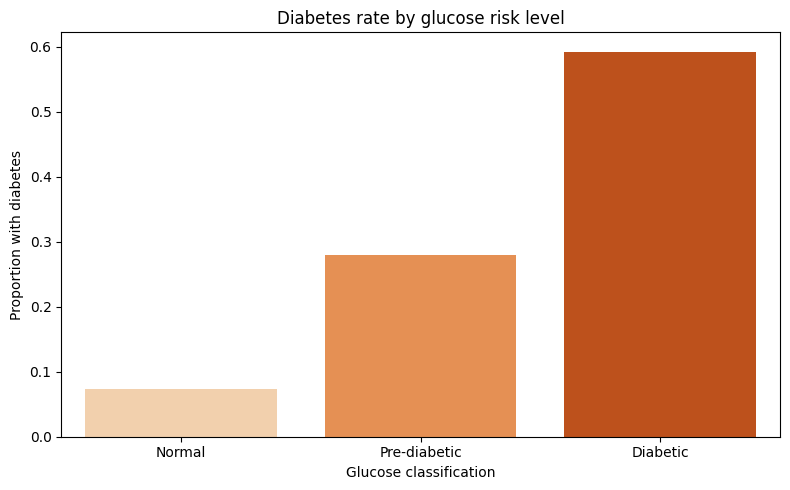

Chart saved!


In [6]:
# Diabetes rate by glucose risk level
glucose_risk = df.groupby('Glucose_Risk', observed=True)['Outcome'].mean().reset_index()
glucose_risk.columns = ['Glucose_Risk', 'Diabetes_Rate']

plt.figure(figsize=(8, 5))
sns.barplot(data=glucose_risk, x='Glucose_Risk', y='Diabetes_Rate', palette='Oranges')
plt.title('Diabetes rate by glucose risk level')
plt.ylabel('Proportion with diabetes')
plt.xlabel('Glucose classification')
plt.tight_layout()
plt.savefig('charts/diabetes_by_glucose.png')
plt.show()
print("Chart saved!")

In [8]:
df.to_csv('data/diabetes_cleaned.csv', index=False)
print("Saved! Rows:", len(df), "| Columns:", len(df.columns))
print("\nFinal columns:")
print(df.columns.tolist())

Saved! Rows: 768 | Columns: 12

Final columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'BMI_Category', 'Age_Group', 'Glucose_Risk']
